# **Traditional Machine Learning Pipeline**

**Dataset**: [Cat vs. Dog](https://www.kaggle.com/datasets/tongpython/cat-and-dog/versions/1)

**Course:** Machine Learning | **Supervisor:** TS. Truong Vinh Lan | **Group 7**

| # | Member | Student ID |
|---|--------|------------|
| 1 | Nguyen Manh Quoc Khanh | 2352525 |
| 2 | Phan Ngoc Lan Chi | 2352137 |
| 3 | Ngo Diem Quyen | 2353031 |
| 4 | Tran Lam Anh | 2352067 |
| 5 | Vu Duc Viet Anh | 2352074 |

---

## Overview

This notebook implements the **Traditional Machine Learning Pipeline** for binary image classification (Cat vs. Dog). Shared modules from `modules/` are reused for
EDA, data utilities, and visualisation — keeping both pipelines consistent.

```
0. Configuration
      |
1. EDA
   1.1 Data setup
   1.2 Label & spatial distribution
   1.3 Image quality metrics
   1.4 Colour & data quality
      |
2. Preprocessing
   2.1 Data cleaning
   2.2 Spatial outlier removal
   2.3 Stratified train / val / test split
   2.4 Data augmentation preview
      |
3. Model Architecture
   3.1 Pretrained backbone selection
   3.2 Classification head design
   3.3 Model summary
      |
4. Training
   4.1 Dataset & DataLoader
   4.2 Loss, optimizer, scheduler
   4.3 Training loop with early stopping
   4.4 Training curves
      |
5. Evaluation
   5.1 Classification report
   5.2 Confusion matrix
   5.3 Misclassified image gallery
   5.4 Grad-CAM visualisation
      |
6. Comparison with Classical Pipeline
      |
7. Conclusion
```


---
## 0. Configuration

Load modules, define workspace paths, and configure the full experiment from one config object.

In [1]:
# ============================================================
# Download modules from GitHub
# ============================================================
!rm -rf /content/modules
!git clone https://github.com/kahn-29/252-MachineLearning-Assignment1.git temp
!cp -r temp/modules .
!rm -rf temp

Cloning into 'temp'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 108 (delta 4), reused 2 (delta 2), pack-reused 89 (from 1)
Receiving objects: 100% (108/108), 85.91 MiB | 6.43 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
# ============================================================
# Environment setup
# ============================================================
import os
import sys
import json
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = Path("/content/")
WORKSPACE = Path("/content/")

sys.path.insert(0, str(REPO_DIR))
os.chdir(REPO_DIR)

print("Repository (for modules discovery):", REPO_DIR)
print("Workspace (for output files):", WORKSPACE)
print("Python:", sys.version)

if not WORKSPACE.exists():
    WORKSPACE.mkdir(parents=True, exist_ok=True)

Repository (for modules discovery): /content
Workspace (for output files): /content
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


### Configuration

Quick reference for the main config groups used by the pipeline.

| Group | Purpose |
|---|---|
| `dataset` | Dataset source, labels, and extensions |
| `preprocessing` | Resize, padding/crop, tensor conversion, normalization |
| `feature_extraction` | CNN backbone and extraction batch size |
| `classifier` | Classical model, CV setting, and parameter grid |
| `cleaning` | Optional quality filters and thresholds |
| `paths` | Output folders for figures, features, reports, and models |

Example, if you want to:
 * modify mage resizing, change `preprocessing.image_size`
 * another pretrained model for feature extraction, change `feature_extraction.back_bone`, options including "efficientnet_b0", "resnet18", and "vgg16".
 * another classification model, change `classifier.name`, options including "logistic_regression", "svm_linear", "random_forest", "voting_soft", and "stacking"

In [3]:
# ============================================================
# User config (change is allow)
# ============================================================

USER_CONFIG = {
    "paths": {
        "workspace": "/content",
        "data_dir": "/content/data",
        "raw_data_dir": "/content/data/raw",
        "processed_data_dir": "/content/data/processed",
        "features_dir": "/content/features",
        "models_dir": "/content/models",
        "reports_dir": "/content/reports",
        "figures_dir": "/content/reports/figures",
        "results_dir": "/content/reports/results"
    }
}

In [4]:
# ============================================================
# Config setup
# ============================================================

from modules.config_utils import (
    get_default_config,
    deep_update,
    validate_config,
    set_seed,
    get_device,
    ensure_dirs,
    config_to_run_name,
    save_config,
)

DEFAULT_CONFIG = get_default_config()
# Overried default config by user config
CONFIG = deep_update(DEFAULT_CONFIG, USER_CONFIG)

# Validate
try:
    validate_config(CONFIG)
except Exception as e:
    print("Config validation warning:", repr(e))

SEED = int(CONFIG.get("seed", 42))

set_seed(SEED, deterministic=False)
DEVICE = get_device()

# Make output folders
for key in ["workspace", "data_dir", "features_dir", "models_dir", "reports_dir", "results_dir", "figures_dir"]:
    if key in CONFIG.get("paths", {}):
        ensure_dirs(CONFIG["paths"][key])

RUN_NAME = config_to_run_name(CONFIG)
CONFIG_PATH = Path(CONFIG["paths"]["reports_dir"]) / f"{RUN_NAME}_config.json"
save_config(CONFIG, CONFIG_PATH)

print("Device:", DEVICE)
print("Run name:", RUN_NAME)
print("Saved config to:", CONFIG_PATH)
print(json.dumps(CONFIG, indent=2, default=str)[:2500])

Device: cpu
Run name: augmented__efficientnet_b0__voting_soft
Saved config to: /content/reports/augmented__efficientnet_b0__voting_soft_config.json
{
  "project": {
    "name": "ml_image_classifier",
    "task": "binary_image_classification",
    "target": "cat_vs_dog"
  },
  "seed": 42,
  "runtime": {
    "deterministic": false,
    "device": "auto",
    "num_workers": 0
  },
  "paths": {
    "workspace": "/content",
    "data_dir": "/content/data",
    "raw_data_dir": "/content/data/raw",
    "processed_data_dir": "/content/data/processed",
    "features_dir": "/content/features",
    "models_dir": "/content/models",
    "reports_dir": "/content/reports",
    "figures_dir": "/content/reports/figures",
    "results_dir": "/content/reports/results"
  },
  "dataset": {
    "dataset_id": "tongpython/cat-and-dog",
    "local_root": null,
    "kaggle_input_dir": "/kaggle/input",
    "extensions": [
      ".jpg",
      ".jpeg",
      ".png",
      ".bmp",
      ".webp"
    ],
    "class_map

---
## 1. Exploratory Data Analysis

Build the image registry and inspect label balance, image geometry, and sample quality.

### 1.1 Data Setup

Resolve the dataset path and build one dataframe row per image.

In [5]:
# ============================================================
# Download dataset and build raw dataframe
# ============================================================

from modules.data_utils import (
    resolve_dataset_root,
    build_raw_dataframe,
    add_image_metadata,
    summarize_class_distribution,
    sample_by_class,
)
from modules.artifacts import save_dataframe

DATASET_CFG = CONFIG.get("dataset", {})
DATASET_ID = DATASET_CFG.get("dataset_id", "tongpython/cat-and-dog")
LOCAL_ROOT = DATASET_CFG.get("local_root")
EXTENSIONS = DATASET_CFG.get("extensions")

print("Dataset ID:", DATASET_ID)

DATASET_ROOT = resolve_dataset_root(
    dataset_id=DATASET_ID,
    local_root=LOCAL_ROOT,
    extensions=EXTENSIONS,
    allow_download=True,
)

print("Dataset root:", DATASET_ROOT)

raw_df = build_raw_dataframe(
    DATASET_ROOT,
    extensions=EXTENSIONS,
    drop_unknown=True,
)

raw_df = add_image_metadata(raw_df, path_col="path")
raw_df["path"] = raw_df["path"].astype(str)

print("Raw dataframe shape:", raw_df.shape)
display(raw_df.head())

raw_df_path = Path(CONFIG["paths"]["results_dir"]) / "raw_dataframe.csv"
save_dataframe(raw_df, raw_df_path, index=False)
print("Saved raw dataframe to:", raw_df_path)

Dataset ID: tongpython/cat-and-dog
Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset root: /kaggle/input/cat-and-dog
Raw dataframe shape: (10028, 12)


,sample_id,path,label,label_name,filename,extension,width,height,channels,aspect_ratio,min_side,max_side
0,0,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4001.jpg,.jpg,498,415,3,1.200000,415,498
1,1,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4002.jpg,.jpg,375,499,3,0.751503,375,499
2,2,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4003.jpg,.jpg,500,399,3,1.253133,399,500
3,3,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4004.jpg,.jpg,499,375,3,1.330667,375,499
4,4,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4005.jpg,.jpg,360,359,3,1.002786,359,360


Saved raw dataframe to: /content/reports/results/raw_dataframe.csv


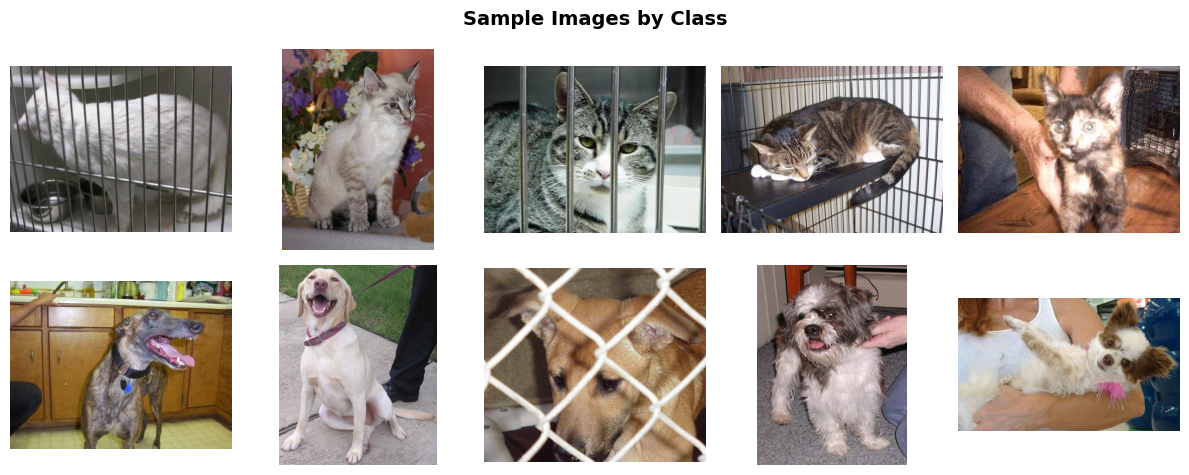

(<Figure size 1200x480 with 10 Axes>,
 array([[<Axes: ylabel='cat'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='dog'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >]],
       dtype=object))

In [6]:
from modules.visualization import plot_sample_grid

FIG_DIR = Path(CONFIG["paths"]["figures_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)

plot_sample_grid(
    raw_df,
    n_per_class=5,
    path_col="path",
    label_col="label_name",
    seed=SEED,
    save_path=FIG_DIR / "eda_sample_grid.png",
    show=True,
)

### 1.2 EDA
> Basic EDA for image data (image size, number of color channels, label distribution, number of samples per class)

In [11]:
from modules.visualization import (
    plot_class_distribution_pie,
    plot_image_size_distribution,
    plot_rgb_channel_kde
)

Label distribution:


,label_name,count,percentage
0,cat,5011,49.97
1,dog,5017,50.03


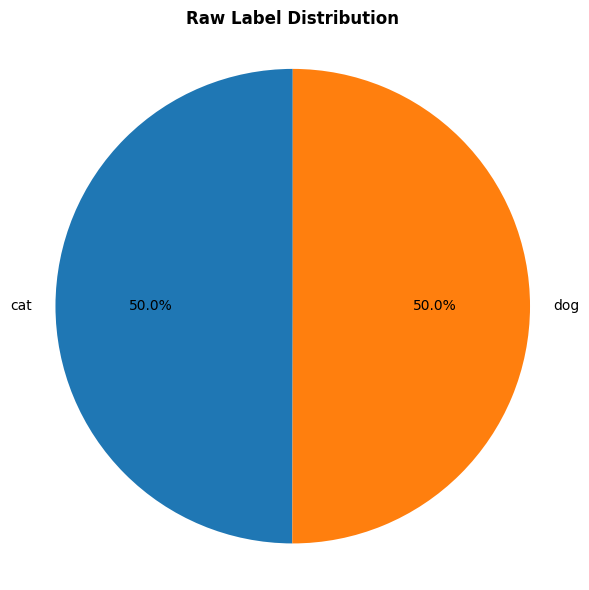

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Raw Label Distribution'}>)

In [8]:
# ============================================================
# Label distribution
# ============================================================
print("Label distribution:")
class_dist = summarize_class_distribution(raw_df, label_col="label_name")
display(class_dist)

plot_class_distribution_pie(
    raw_df,
    label_col="label_name",
    title="Raw Label Distribution",
    save_path=FIG_DIR / "eda_label_distribution_pie.png",
    show=True,
)

Image size summary:


,count,mean,std,min,25%,50%,75%,max
width,10028.0,403.997108,108.753655,57.000000,322.000000,446.500000,499.000000,1050.000000
height,10028.0,360.507379,96.945867,33.000000,300.000000,374.000000,422.000000,768.000000
channels,10028.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000
aspect_ratio,10028.0,1.156889,0.292263,0.376884,0.927856,1.272959,1.336898,5.909091
min_side,10028.0,334.025828,85.397003,33.000000,282.000000,366.000000,375.000000,768.000000
max_side,10028.0,430.478660,101.128358,57.000000,360.000000,499.000000,500.000000,1050.000000


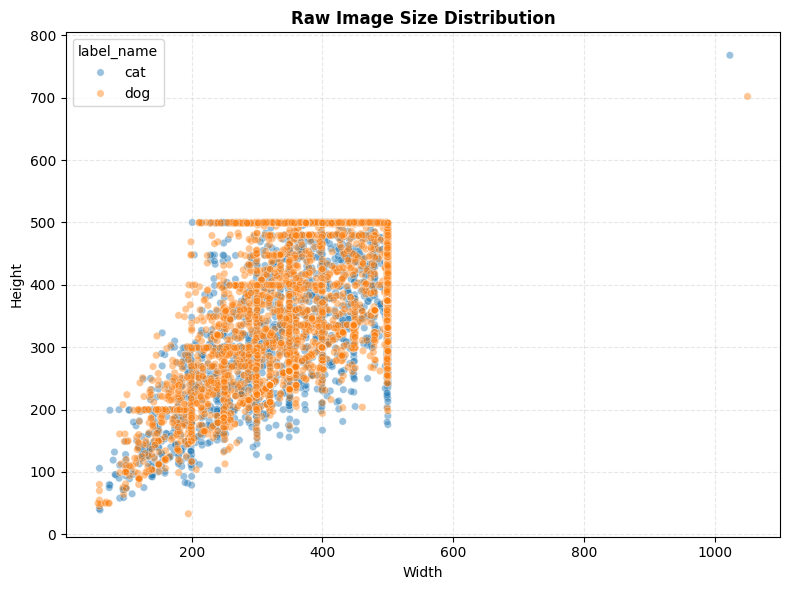

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Raw Image Size Distribution'}, xlabel='Width', ylabel='Height'>)

In [9]:
# ============================================================
# Image size
# ============================================================
print("Image size summary:")
size_cols = [c for c in ["width", "height", "aspect_ratio", "min_side", "max_side"] if c in raw_df.columns]
display(raw_df[size_cols].describe().T)

plot_image_size_distribution(
    raw_df,
    width_col="width",
    height_col="height",
    label_col="label_name",
    title="Raw Image Size Distribution",
    save_path=FIG_DIR / "eda_image_size_distribution.png",
    show=True,
)

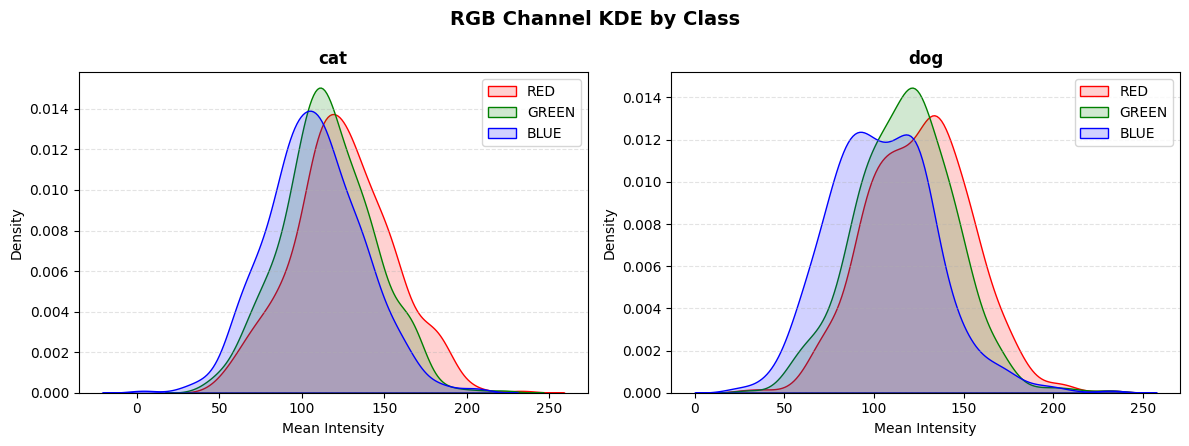

(<Figure size 1200x450 with 2 Axes>,
 array([<Axes: title={'center': 'cat'}, xlabel='Mean Intensity', ylabel='Density'>,
        <Axes: title={'center': 'dog'}, xlabel='Mean Intensity', ylabel='Density'>],
       dtype=object))

In [13]:
# ============================================================
# Channel distribtion
# ============================================================
plot_rgb_channel_kde(
    df=raw_df,
    sample_per_class=500,
    save_path=FIG_DIR / "eda_rgb_channel_distribution_kde.png",
    show=True,
    class_order=["cat", "dog"]
)

### 1.3 Image Quality Audit

Compute audit metrics used for reporting and optional cleaning.

In [16]:
# ============================================================
# Optional audit metrics
# ============================================================

# Since the audit only use to apply cleaning, if cleaning is dissable, the audit is unnecessary
if CONFIG.get("cleaning", {}).get("enabled", False):
    from modules.image_audit import audit_dataframe, describe_audit_metrics

    # Full audit supports cleaning and report figures.
    # compute_hash=False
    audit_df = audit_dataframe(
        raw_df,
        path_col="path",
        label_col="label",
        label_name_col="label_name",
        compute_hash=False,
        preserve_cols=["sample_id", "path", "label", "label_name", "filename", "extension"],
        show_progress=True,
    )

    audit_path = Path(CONFIG["paths"]["results_dir"]) / "image_audit.csv"
    save_dataframe(audit_df, audit_path, index=False)
    print("Saved audit dataframe to:", audit_path)

    print("Audit metric summary:")
    audit_stats = describe_audit_metrics(audit_df)
    display(audit_stats.round(3))
    save_dataframe(audit_stats, Path(CONFIG["paths"]["results_dir"]) / "image_audit_summary.csv", index=True)

### 1.4 EDA Summary

| # | Finding | Evidence | Decision |
|---|---------|----------|----------------------|
| 1 | Balanced classes | ~50% cat / ~50% dog | No class weighting required |
| 2 | High resolution variability | Width std ~108 px | Resize to 224x224 with Augmented |
| 3 | Blur is dominant quality issue | Laplacian var < 40 for ~2-3% | Apply blur threshold filter |
| 4 | No colour discriminability | R/G/B KDE overlaps | Model relies on shape/texture |
| 5 | Near-zero missing values | 0 nulls in metadata | No imputation needed |

---
## 2. Preprocessing

Clean the dataset, split it into train/validation/test sets, and build image transforms.

### 2.1 Data Cleaning

Apply config-based filters and keep removed samples for reporting.
 >Small note: About cleaning process in preprocessing, base on our experiments, the best result return when no clean (keep 100% data). So if you want to apply cleaning, please modify `cleaning` in configuration.

In [17]:
# ============================================================
# Data cleaning
# ============================================================
# Apply cleaning only when enabled in CONFIG.
# Preserve removed_df so filtering decisions can be reported.

from modules.cleaning import (
    apply_cleaning,
    summarize_cleaning,
    summarize_removal_reasons,
    evaluate_cleaning_retention,
)

CLEANING_CFG = CONFIG.get("cleaning", {})

if CLEANING_CFG.get("enabled", False):
    clean_df, removed_df = apply_cleaning(audit_df, CLEANING_CFG)
    print("Cleaning enabled.")
else:
    clean_df = raw_df.copy()
    removed_df = raw_df.iloc[0:0].copy()
    print("Cleaning disabled. Using all raw images.")

print("Raw samples:", len(raw_df))
print("Clean samples:", len(clean_df))
print("Removed samples:", len(removed_df))

clean_summary = summarize_cleaning(raw_df, clean_df, removed_df, label_col="label_name")
display(clean_summary)

save_dataframe(clean_df, Path(CONFIG["paths"]["results_dir"]) / "clean_dataframe.csv", index=False)
save_dataframe(removed_df, Path(CONFIG["paths"]["results_dir"]) / "removed_dataframe.csv", index=False)
save_dataframe(clean_summary, Path(CONFIG["paths"]["results_dir"]) / "cleaning_summary.csv", index=False)

if len(removed_df) > 0:
    reason_summary = summarize_removal_reasons(removed_df)
    display(reason_summary)
    save_dataframe(reason_summary, Path(CONFIG["paths"]["results_dir"]) / "removal_reasons.csv", index=False)

retention_info = evaluate_cleaning_retention(raw_df, clean_df, label_col="label")
print("Retention info:")
print(json.dumps(retention_info, indent=2, default=str))

Cleaning disabled. Using all raw images.
Raw samples: 10028
Clean samples: 10028
Removed samples: 0


,label_name,count_before,count_after,count_removed,pct_before,pct_after,removal_rate_pct
0,cat,5011,5011,0,49.97,49.97,0.0
1,dog,5017,5017,0,50.03,50.03,0.0
2,TOTAL,10028,10028,0,100.00,100.00,0.0


Retention info:
{
  "n_before": 10028,
  "n_after": 10028,
  "n_removed": 0,
  "retention_rate": 1.0,
  "removal_rate": 0.0,
  "retention_pct": 100.0,
  "removal_pct": 0.0,
  "class_balance_shift": 0.0,
  "class_balance_shift_pct": 0.0
}


### 2.2 Stratified Split

Create train, validation, and test sets while preserving class ratios.

Train: (8022, 13)
Val:   (1003, 13)
Test:  (1003, 13)


,split,split_size,label_name,count,percentage
0,train,8022,cat,4009,49.98
1,train,8022,dog,4013,50.02
2,val,1003,cat,501,49.95
3,val,1003,dog,502,50.05
4,test,1003,cat,501,49.95
5,test,1003,dog,502,50.05


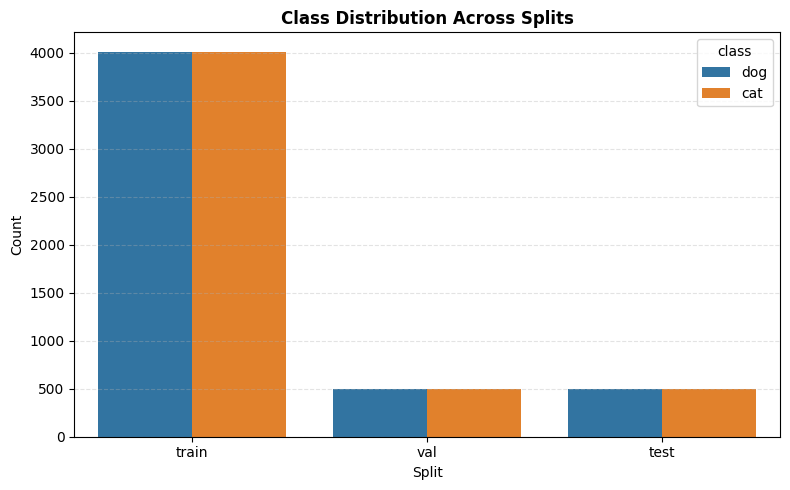

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Class Distribution Across Splits'}, xlabel='Split', ylabel='Count'>)

In [18]:
# ============================================================
# Stratified train / validation / test split
# ============================================================

from modules.data_utils import stratified_split, summarize_split_distribution
from modules.visualization import plot_split_distribution

SPLIT_CFG = CONFIG.get("split", {})

train_df, val_df, test_df = stratified_split(
    clean_df,
    train_ratio=float(SPLIT_CFG.get("train_ratio", 0.8)),
    val_ratio=float(SPLIT_CFG.get("val_ratio", 0.1)),
    test_ratio=float(SPLIT_CFG.get("test_ratio", 0.1)),
    seed=int(CONFIG.get("seed", 42)),
    label_col="label",
)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

split_dist = summarize_split_distribution(train_df, val_df, test_df, label_col="label_name")
display(split_dist)

save_dataframe(train_df, Path(CONFIG["paths"]["results_dir"]) / "train_dataframe.csv", index=False)
save_dataframe(val_df, Path(CONFIG["paths"]["results_dir"]) / "val_dataframe.csv", index=False)
save_dataframe(test_df, Path(CONFIG["paths"]["results_dir"]) / "test_dataframe.csv", index=False)
save_dataframe(split_dist, Path(CONFIG["paths"]["results_dir"]) / "split_distribution.csv", index=False)

plot_split_distribution(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_col="label_name",
    save_path=FIG_DIR / "split_distribution.png",
    show=True,
)

### 2.3 Image Transforms

Build train and evaluation transforms from config.

In [19]:
# ============================================================
# Build preprocessing transforms from config
# ============================================================
# Build train/eval image transforms from preprocessing config.
# Use deterministic eval transform for validation and test features.

from modules.transforms import build_image_transform, transform_image_to_array

train_transform = build_image_transform(CONFIG["preprocessing"], split="train")
eval_transform = build_image_transform(CONFIG["preprocessing"], split="eval")

print("Train transform:")
print(train_transform)

print("\nEval transform:")
print(eval_transform)

Train transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


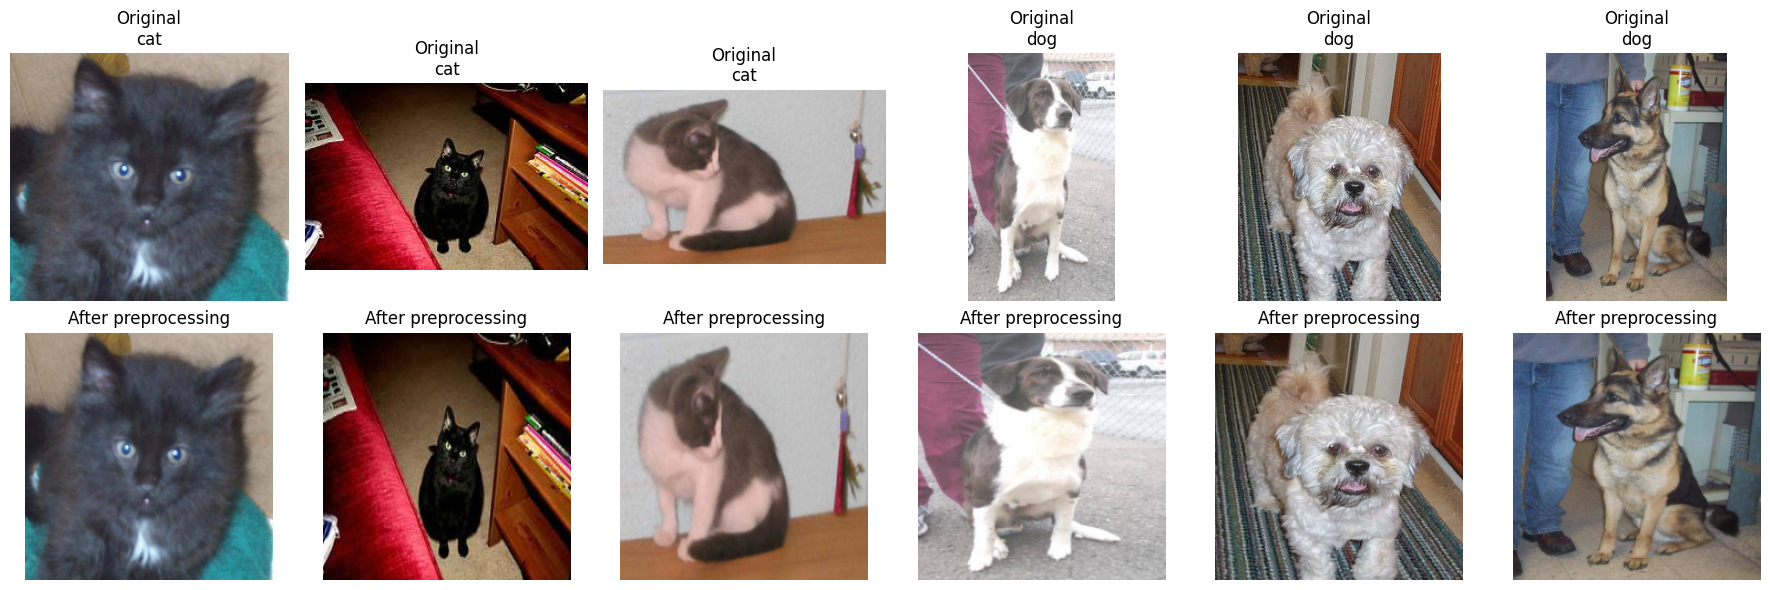

In [20]:
# ============================================================
# Preview transformed images
# ============================================================

from PIL import Image
from modules.transforms import tensor_to_display_image

preview_df = sample_by_class(train_df, n_per_class=3, label_col="label_name", seed=int(CONFIG.get("seed", 42)))

n = len(preview_df)
fig, axes = plt.subplots(2, n, figsize=(3*n, 6))

for j, (_, row) in enumerate(preview_df.iterrows()):
    path = row["path"]
    label = row["label_name"]

    original = Image.open(path).convert("RGB")
    transformed_tensor = eval_transform(original)
    transformed = tensor_to_display_image(transformed_tensor, denormalize=True, normalize=CONFIG["preprocessing"].get("normalize", "imagenet"))

    axes[0, j].imshow(original)
    axes[0, j].set_title(f"Original\n{label}")
    axes[0, j].axis("off")

    axes[1, j].imshow(transformed)
    axes[1, j].set_title("After preprocessing")
    axes[1, j].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "preprocessing_preview.png", dpi=160, bbox_inches="tight")
plt.show()

---
## 3. Feature Extraction

Extract frozen CNN features and save them as `.npy` arrays for subsequent
classification models.

In [21]:
# ============================================================
# Extract or load frozen deep features
# ============================================================

import gc
import torch

from modules.feature_extraction import extract_feature_splits
from modules.backbones import get_feature_dim

FEATURE_CFG = CONFIG.get("feature_extraction", {})
BACKBONE = FEATURE_CFG.get("backbone", "efficientnet_b0")

feature_dir = Path(CONFIG["paths"]["features_dir"]) / RUN_NAME / BACKBONE
feature_dir.mkdir(parents=True, exist_ok=True)

batch_size = int(FEATURE_CFG.get("batch_size", 64))
if BACKBONE == "vgg16":
    batch_size = min(batch_size, 16)

num_workers = 0

print("Backbone:", BACKBONE)
print("Feature dimension:", get_feature_dim(BACKBONE))
print("Feature output directory:", feature_dir)
print("Batch size:", batch_size)

Backbone: efficientnet_b0
Feature dimension: 1280
Feature output directory: /content/features/augmented__efficientnet_b0__voting_soft/efficientnet_b0
Batch size: 128


In [22]:
start_time = time.time()

feature_result = extract_feature_splits(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    train_transform=train_transform,
    eval_transform=eval_transform,
    backbone_name=BACKBONE,
    batch_size=batch_size,
    device=DEVICE,
    num_workers=num_workers,
    output_dir=feature_dir,
    pretrained=bool(FEATURE_CFG.get("pretrained", True)),
    data_parallel=False,
    force_recompute=bool(FEATURE_CFG.get("force_recompute", False)),
    path_col="path",
    label_col="label",
    show_progress=True,
    on_error=str(FEATURE_CFG.get("on_error", "raise")),
)

feature_seconds = time.time() - start_time
print(f"Feature extraction time: {feature_seconds:.2f} seconds")
print("Loaded from cache:", feature_result.get("loaded_from_cache"))

for key in ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"]:
    arr = np.asarray(feature_result[key])
    print(f"{key}: {arr.shape} | dtype={arr.dtype}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 108MB/s] 


Extracting features (efficientnet_b0):   0%|          | 0/63 [00:00<?, ?it/s]

Extracting features (efficientnet_b0):   0%|          | 0/8 [00:00<?, ?it/s]

Extracting features (efficientnet_b0):   0%|          | 0/8 [00:00<?, ?it/s]

Feature extraction time: 1109.04 seconds
Loaded from cache: False
X_train: (8022, 1280) | dtype=float32
y_train: (8022,) | dtype=int64
X_val: (1003, 1280) | dtype=float32
y_val: (1003,) | dtype=int64
X_test: (1003, 1280) | dtype=float32
y_test: (1003,) | dtype=int64


---
## 4. Traditional Classifier Training

Train a baseline classifier, tune hyperparameters, and select the best model.

### 4.1 Load Feature Arrays

Load saved train, validation, and test features

In [ ]:
# ============================================================
# Load feature arrays
# ============================================================

X_train = np.load(feature_dir / "X_train.npy")
y_train = np.load(feature_dir / "y_train.npy")
X_val = np.load(feature_dir / "X_val.npy")
y_val = np.load(feature_dir / "y_val.npy")
X_test = np.load(feature_dir / "X_test.npy")
y_test = np.load(feature_dir / "y_test.npy")

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (8022, 1280) y_train: (8022,)
X_val:   (1003, 1280) y_val:   (1003,)
X_test:  (1003, 1280) y_test:  (1003,)


### 4.2 Build Classifier

Create the selected classifier and parameter grid from config.

In [ ]:
# ============================================================
# Build classifier and param grid from config
# ============================================================

from modules.classical_models import get_classifier, get_param_grid, train_classifier, tune_classifier_grid, tune_with_params
from modules.artifacts import save_pickle, save_json


CLASSIFIER_CFG = CONFIG.get("classifier", {})
CLASSIFIER_NAME = CLASSIFIER_CFG.get("name", "logistic_regression")

# Tuning parameters from top-level tune-hyperparameter config
TUNE_CFG = CONFIG.get("tune-hyperparameter", {})
TUNE_ENABLED = bool(TUNE_CFG.get("enabled", True))
GRID_SIZE = TUNE_CFG.get("grid_size", "small")
CV = int(TUNE_CFG.get("cv", 3))
SCORING = TUNE_CFG.get("scoring", "f1_macro")
N_JOBS = int(TUNE_CFG.get("n_jobs", -1))
SEED = int(CONFIG.get("seed", 42))

print("Classifier:", CLASSIFIER_NAME)
print("Tuning enabled:", TUNE_ENABLED)
print("Tune config (CV={}, n_jobs={}):".format(CV, N_JOBS))
print("  - scoring:", SCORING)
print("  - grid_size:", GRID_SIZE)

# Always use get_param_grid for grid search (config params are for fixed training only)
PARAM_GRID = get_param_grid(CLASSIFIER_NAME, GRID_SIZE)

print("\nParameter grid:")
print(json.dumps(PARAM_GRID, indent=2, default=str))

Classifier: voting_soft
CV: 3
Scoring: f1_macro
Parameter grid:
{
  "lr__clf__C": [
    0.1,
    1.0
  ],
  "svm__clf__C": [
    0.1,
    1.0
  ],
  "rf__n_estimators": [
    100
  ],
  "rf__max_depth": [
    null,
    10
  ],
  "weights": [
    [
      1,
      1,
      1
    ],
    [
      2,
      1,
      1
    ],
    [
      1,
      2,
      1
    ]
  ]
}


### 4.3 Baseline Training

Train an untuned model to establish a reference score.

In [ ]:
# ============================================================
# 4.3 Train untuned baseline classifier
# ============================================================
# Train baseline model before tuning for comparison.

from modules.evaluation import compute_classification_metrics

baseline_start = time.time()

baseline_model = train_classifier(
    X_train,
    y_train,
    classifier_name=CLASSIFIER_NAME,
    seed=SEED,
)

baseline_seconds = time.time() - baseline_start

baseline_val_pred = baseline_model.predict(X_val)
baseline_val_prob = baseline_model.predict_proba(X_val) if hasattr(baseline_model, "predict_proba") else None
baseline_val_metrics = compute_classification_metrics(y_val, baseline_val_pred, baseline_val_prob)

print(f"Baseline training time: {baseline_seconds:.2f} seconds")
print("Baseline validation metrics:")
print(json.dumps(baseline_val_metrics, indent=2, default=str))

MODEL_DIR = Path(CONFIG["paths"]["models_dir"]) / RUN_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

save_pickle(baseline_model, MODEL_DIR / "baseline_model.pkl")
save_json(baseline_val_metrics, Path(CONFIG["paths"]["results_dir"]) / "baseline_val_metrics.json")

Baseline training time: 55.29 seconds
Baseline validation metrics:
{
  "accuracy": 0.9940179461615155,
  "precision_macro": 0.994045488886238,
  "recall_macro": 0.9940219163267091,
  "f1_macro": 0.9940178926441352,
  "wrong_predictions": 6,
  "total_samples": 1003,
  "error_rate": 0.005982053838484547,
  "roc_auc": 0.9999522866617363
}


### 4.4 Hyperparameter Tuning

Use GridSearchCV to select the best model configuration.

In [ ]:
# ============================================================
# 4.4 Hyperparameter tuning / fine-tuning with GridSearchCV
# ============================================================
# Tune hyperparameters using training features only.

start_time = time.time()

search = tune_with_params(
    X_train=X_train,
    y_train=y_train,
    classifier_name=CLASSIFIER_NAME,
    param_grid=PARAM_GRID,
    cv=CV,
    seed=SEED,
    scoring=SCORING,
    n_jobs=N_JOBS,
    verbose=1,
    return_train_score=True,
)

tuning_seconds = time.time() - start_time
best_model = search.best_estimator_

print(f"Tuning time: {tuning_seconds:.2f} seconds")
print("Best CV score:", search.best_score_)
print("Best params:", search.best_params_)

cv_results_df = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
display(cv_results_df.head(10)[["rank_test_score", "mean_test_score", "std_test_score", "params"]])

save_pickle(search, MODEL_DIR / "grid_search.pkl")
save_pickle(best_model, MODEL_DIR / "best_tuned_model.pkl")
cv_results_df.to_csv(Path(CONFIG["paths"]["results_dir"]) / "classifier_cv_results.csv", index=False)

save_json(
    {
        "classifier": CLASSIFIER_NAME,
        "backbone": BACKBONE,
        "best_cv_score": float(search.best_score_),
        "best_params": search.best_params_,
        "tuning_seconds": float(tuning_seconds),
        "scoring": SCORING,
        "cv": CV,
    },
    Path(CONFIG["paths"]["results_dir"]) / "tuning_summary.json",
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tuning time: 1813.77 seconds
Best CV score: 0.9917725906564133
Best params: {'lr__clf__C': 1.0, 'rf__max_depth': None, 'rf__n_estimators': 100, 'svm__clf__C': 0.1, 'weights': (1, 1, 1)}


,rank_test_score,mean_test_score,std_test_score,params
12,1,0.991773,0.000529,"{'lr__clf__C': 1.0, 'rf__max_depth': None, 'rf..."
15,1,0.991773,0.000529,"{'lr__clf__C': 1.0, 'rf__max_depth': None, 'rf..."
21,3,0.991773,0.000611,"{'lr__clf__C': 1.0, 'rf__max_depth': 10, 'rf__..."
18,3,0.991773,0.000611,"{'lr__clf__C': 1.0, 'rf__max_depth': 10, 'rf__..."
19,5,0.991648,0.000636,"{'lr__clf__C': 1.0, 'rf__max_depth': 10, 'rf__..."
22,5,0.991648,0.000636,"{'lr__clf__C': 1.0, 'rf__max_depth': 10, 'rf__..."
1,7,0.991648,0.000982,"{'lr__clf__C': 0.1, 'rf__max_depth': None, 'rf..."
4,7,0.991648,0.000982,"{'lr__clf__C': 0.1, 'rf__max_depth': None, 'rf..."
13,9,0.991523,0.000466,"{'lr__clf__C': 1.0, 'rf__max_depth': None, 'rf..."
16,9,0.991523,0.000466,"{'lr__clf__C': 1.0, 'rf__max_depth': None, 'rf..."


---
## 5. Evaluation

Evaluate the tuned classifier on train, validation, and test splits.

### 5.1 Split-Level Metrics

Compute metrics on train, validation, and test data.

In [ ]:
# ============================================================
# 5.1 Evaluate tuned classifier on train / val / test
# ============================================================
# Compare split metrics to check generalization.

from modules.evaluation import (
    compute_classification_metrics,
    classification_report_df,
    confusion_matrix_df,
    find_wrong_predictions,
)

LABELS = [0, 1]
LABEL_NAMES = ["cat", "dog"]


def predict_and_evaluate(model, X, y, split_name):
    y_pred = model.predict(X)

    y_prob = None
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X)
        except Exception:
            y_prob = None

    metrics = compute_classification_metrics(y, y_pred, y_prob)
    report = classification_report_df(y, y_pred, labels=LABELS, label_names=LABEL_NAMES)
    cm = confusion_matrix_df(y, y_pred, labels=LABELS, label_names=LABEL_NAMES)

    print(f"\n{split_name.upper()} metrics")
    print(json.dumps(metrics, indent=2, default=str))

    return {
        "split": split_name,
        "y_true": y,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "metrics": metrics,
        "report": report,
        "cm": cm,
    }

results = {
    "train": predict_and_evaluate(best_model, X_train, y_train, "train"),
    "val": predict_and_evaluate(best_model, X_val, y_val, "val"),
    "test": predict_and_evaluate(best_model, X_test, y_test, "test"),
}

metrics_rows = []
for split_name, result in results.items():
    row = {
        "run_name": RUN_NAME,
        "backbone": BACKBONE,
        "classifier": CLASSIFIER_NAME,
        "split": split_name,
        "best_cv_score": float(search.best_score_),
        "tuning_seconds": float(tuning_seconds),
        **result["metrics"],
    }
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

metrics_df.to_csv(Path(CONFIG["paths"]["results_dir"]) / "final_train_val_test_metrics.csv", index=False)

for split_name, result in results.items():
    save_json(result["metrics"], Path(CONFIG["paths"]["results_dir"]) / f"{split_name}_metrics.json")
    result["report"].to_csv(Path(CONFIG["paths"]["results_dir"]) / f"{split_name}_classification_report.csv")
    result["cm"].to_csv(Path(CONFIG["paths"]["results_dir"]) / f"{split_name}_confusion_matrix.csv")


TRAIN metrics
{
  "accuracy": 1.0,
  "precision_macro": 1.0,
  "recall_macro": 1.0,
  "f1_macro": 1.0,
  "wrong_predictions": 0,
  "total_samples": 8022,
  "error_rate": 0.0,
  "roc_auc": 1.0
}

VAL metrics
{
  "accuracy": 0.9940179461615155,
  "precision_macro": 0.994045488886238,
  "recall_macro": 0.9940219163267091,
  "f1_macro": 0.9940178926441352,
  "wrong_predictions": 6,
  "total_samples": 1003,
  "error_rate": 0.005982053838484547,
  "roc_auc": 0.9999522866617363
}

TEST metrics
{
  "accuracy": 0.996011964107677,
  "precision_macro": 0.9960178926441352,
  "recall_macro": 0.9960139481992191,
  "f1_macro": 0.996011960143458,
  "wrong_predictions": 4,
  "total_samples": 1003,
  "error_rate": 0.003988035892323031,
  "roc_auc": 0.9998608360967309
}


,run_name,backbone,classifier,split,best_cv_score,tuning_seconds,accuracy,precision_macro,recall_macro,f1_macro,wrong_predictions,total_samples,error_rate,roc_auc
0,augmented__efficientnet_b0__voting_soft,efficientnet_b0,voting_soft,train,0.991773,1813.774882,1.000000,1.000000,1.000000,1.000000,0,8022,0.000000,1.000000
1,augmented__efficientnet_b0__voting_soft,efficientnet_b0,voting_soft,val,0.991773,1813.774882,0.994018,0.994045,0.994022,0.994018,6,1003,0.005982,0.999952
2,augmented__efficientnet_b0__voting_soft,efficientnet_b0,voting_soft,test,0.991773,1813.774882,0.996012,0.996018,0.996014,0.996012,4,1003,0.003988,0.999861


### 5.2 Report and Confusion Matrix

Inspect per-class scores and prediction errors.

Test classification report:


,precision,recall,f1-score,support
cat,0.994036,0.998004,0.996016,501.000000
dog,0.998000,0.994024,0.996008,502.000000
accuracy,0.996012,0.996012,0.996012,0.996012
macro avg,0.996018,0.996014,0.996012,1003.000000
weighted avg,0.996020,0.996012,0.996012,1003.000000


Test confusion matrix:


,Predicted cat,Predicted dog
Actual cat,500,1
Actual dog,3,499


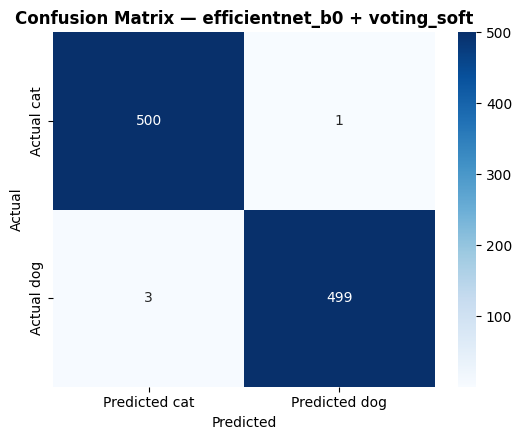

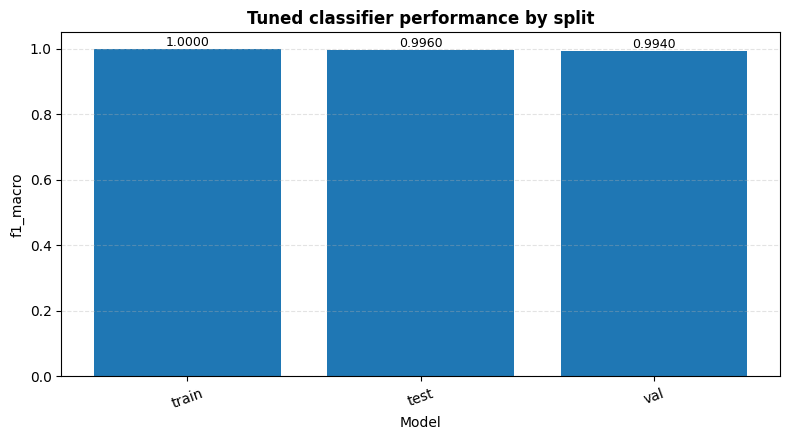

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Tuned classifier performance by split'}, xlabel='Model', ylabel='f1_macro'>)

In [ ]:
# ============================================================
# 5.2 Classification report and confusion matrix
# ============================================================
# Report per-class scores and visualize class-level errors.

from modules.visualization import plot_confusion_matrix, plot_model_comparison

print("Test classification report:")
display(results["test"]["report"])

print("Test confusion matrix:")
display(results["test"]["cm"])

plot_confusion_matrix(
    results["test"]["cm"],
    labels=LABEL_NAMES,
    title=f"Confusion Matrix — {BACKBONE} + {CLASSIFIER_NAME}",
    save_path=FIG_DIR / "test_confusion_matrix.png",
    show=True,
)

plot_model_comparison(
    metrics_df,
    metric="f1_macro",
    model_col="split",
    title="Tuned classifier performance by split",
    save_path=FIG_DIR / "train_val_test_f1_comparison.png",
    show=True,
)

**Check:** most predictions should fall on the diagonal of the confusion matrix.

### 5.3 Wrong Prediction Gallery

Review misclassified test images.

Wrong predictions on test set: 4 / 1003


,path,true_label,pred_label,true_label_name,pred_label_name,confidence,is_correct
0,/kaggle/input/cat-and-dog/training_set/trainin...,1,0,dog,cat,0.878026,False
1,/kaggle/input/cat-and-dog/training_set/trainin...,1,0,dog,cat,0.821169,False
2,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,1,cat,dog,0.624833,False
3,/kaggle/input/cat-and-dog/test_set/test_set/do...,1,0,dog,cat,0.749623,False


Saved wrong predictions to: /content/ml_image_classifier/reports/results/test_wrong_predictions.csv


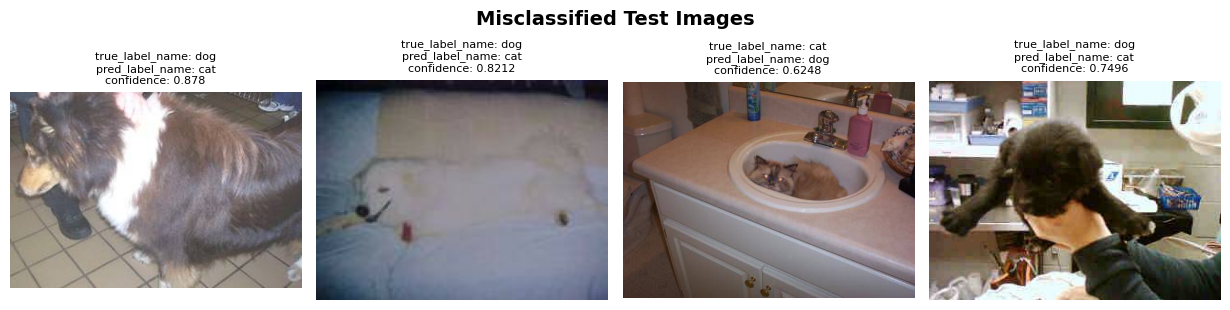

In [ ]:
# ============================================================
# 5.3 Misclassified image gallery
# ============================================================
# Inspect test mistakes using original image paths.

wrong_df = find_wrong_predictions(
    test_df.reset_index(drop=True),
    y_true=results["test"]["y_true"],
    y_pred=results["test"]["y_pred"],
    y_prob=results["test"]["y_prob"],
    path_col="path",
    label_map={0: "cat", 1: "dog"},
)

print(f"Wrong predictions on test set: {len(wrong_df)} / {len(test_df)}")
display(wrong_df.head(20))

wrong_path = Path(CONFIG["paths"]["results_dir"]) / "test_wrong_predictions.csv"
wrong_df.to_csv(wrong_path, index=False)
print("Saved wrong predictions to:", wrong_path)

if len(wrong_df) > 0:
    from modules.visualization import plot_image_grid_from_df

    # Choose available subtitle columns safely
    subtitle_cols = [c for c in ["true_label_name", "pred_label_name", "confidence"] if c in wrong_df.columns]

    plot_image_grid_from_df(
        wrong_df,
        n=min(12, len(wrong_df)),
        path_col="path",
        title_col="filename" if "filename" in wrong_df.columns else None,
        subtitle_cols=subtitle_cols,
        n_cols=4,
        suptitle="Misclassified Test Images",
        save_path=FIG_DIR / "test_wrong_predictions_grid.png",
        show=True,
    )

**Check:** wrong predictions should be inspected for blur, occlusion, label noise, or unusual poses.

### 5.4 Experiment Summary

Save the final metrics and run metadata.

In [ ]:
# ============================================================
# 5.4 Final experiment summary
# ============================================================
# Store final run metadata and metrics for the report.

final_summary = {
    "run_name": RUN_NAME,
    "dataset_id": DATASET_ID,
    "n_raw_samples": int(len(raw_df)),
    "n_clean_samples": int(len(clean_df)),
    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),
    "preprocessing": CONFIG.get("preprocessing", {}),
    "backbone": BACKBONE,
    "feature_dim": int(get_feature_dim(BACKBONE)),
    "classifier": CLASSIFIER_NAME,
    "best_params": search.best_params_,
    "best_cv_score": float(search.best_score_),
    "feature_seconds": float(feature_seconds),
    "baseline_seconds": float(baseline_seconds),
    "tuning_seconds": float(tuning_seconds),
    "test_metrics": results["test"]["metrics"],
}

summary_path = Path(CONFIG["paths"]["results_dir"]) / "final_experiment_summary.json"
save_json(final_summary, summary_path)

print("Final experiment summary:")
print(json.dumps(final_summary, indent=2, default=str))
print("Saved to:", summary_path)

Final experiment summary:
{
  "run_name": "augmented__efficientnet_b0__voting_soft",
  "dataset_id": "tongpython/cat-and-dog",
  "n_raw_samples": 10028,
  "n_clean_samples": 10028,
  "train_samples": 8022,
  "val_samples": 1003,
  "test_samples": 1003,
  "preprocessing": {
    "mode": "augmented",
    "image_size": 224,
    "train_augmentation": false,
    "normalize": "imagenet"
  },
  "backbone": "efficientnet_b0",
  "feature_dim": 1280,
  "classifier": "voting_soft",
  "best_params": {
    "lr__clf__C": 1.0,
    "rf__max_depth": null,
    "rf__n_estimators": 100,
    "svm__clf__C": 0.1,
    "weights": [
      1,
      1,
      1
    ]
  },
  "best_cv_score": 0.9917725906564133,
  "feature_seconds": 71.92658281326294,
  "baseline_seconds": 55.28795051574707,
  "tuning_seconds": 1813.7748816013336,
  "test_metrics": {
    "accuracy": 0.996011964107677,
    "precision_macro": 0.9960178926441352,
    "recall_macro": 0.9960139481992191,
    "f1_macro": 0.996011960143458,
    "wrong_predi

---
## 6. Export Artifacts

Package figures, reports, models, config files, and feature arrays for submission.

### 6.1 Export Package

Create one downloadable archive for submission.

In [ ]:
# ============================================================
# 6.1 Zip all important outputs
# ============================================================
# Package models, figures, reports, config, and features for submission.

from datetime import datetime
from google.colab import files

INCLUDE_FEATURES = True

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_root = WORKSPACE / f"classical_export_{timestamp}"
export_root.mkdir(parents=True, exist_ok=True)

folders_to_copy = {
    "models": Path(CONFIG["paths"]["models_dir"]),
    "reports": Path(CONFIG["paths"]["reports_dir"]),
}

if INCLUDE_FEATURES:
    folders_to_copy["features"] = Path(CONFIG["paths"]["features_dir"])

for name, src in folders_to_copy.items():
    if src.exists():
        shutil.copytree(src, export_root / name, dirs_exist_ok=True)
        print(f"Copied {name}: {src}")
    else:
        print(f"Skipped missing folder: {src}")

manifest = export_root / "MANIFEST.txt"
with open(manifest, "w", encoding="utf-8") as f:
    f.write("Classical ML Cat-Dog Pipeline Export\n")
    f.write("=" * 60 + "\n")
    f.write(f"Run name: {RUN_NAME}\n")
    f.write(f"Dataset: {DATASET_ID}\n")
    f.write(f"Backbone: {BACKBONE}\n")
    f.write(f"Classifier: {CLASSIFIER_NAME}\n")
    f.write(f"Export time: {timestamp}\n\n")
    f.write("Included folders:\n")
    for name in folders_to_copy:
        f.write(f"- {name}/\n")

zip_base = WORKSPACE / f"classical_pipeline_outputs_{timestamp}"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=export_root)

print("Created zip:", zip_path)
files.download(zip_path)

Copied models: /content/ml_image_classifier/models
Copied reports: /content/ml_image_classifier/reports
Copied features: /content/ml_image_classifier/features
Created zip: /content/cat_dog_classical_ml/classical_pipeline_outputs_20260508_101101.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 7. Conclusion

### Final Notes

- The pipeline uses a pretrained CNN as a frozen feature extractor.
- The final classifier is a classical machine-learning model.
- Evaluation is performed on a held-out test set.
- Wrong predictions are saved for qualitative review.

### Limitations

- Frozen features are not specialized to this dataset.
- Noisy or mislabeled samples may still affect results.
- Large feature files may increase storage cost.

### Next Steps

- Compare multiple CNN backbones.
- Compare more classifiers and parameter grids.
- Add PCA or feature selection.
- Compare against the deep-learning pipeline.